In [20]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import yaml

project_root  = Path.cwd().resolve().parent.parent
processed_dir = project_root / 'src' / 'data' / 'processed'
models_dir = project_root / 'src' / 'evaluation'
baseline_dir = project_root / 'src' / 'baseline'

with open(project_root / 'src' / 'config.yaml') as f:
    config = yaml.safe_load(f)

figures_dir = project_root / 'src' / 'evaluation' / config['paths']['model_filename']
figures_dir.mkdir(exist_ok=True)

# Load experiment summary
with open(models_dir / 'experiment_summary.json') as f:
    experiments = json.load(f)

# Load baseline results
with open(baseline_dir / 'baseline.json') as f:
    baseline = json.load(f)

summary_df = pd.DataFrame(experiments)
print(summary_df[['experiment', 'architecture', 'accuracy', 'uq_low_acc', 'uq_high_acc']])

plt.style.use('default')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'grid.color':       '#e0e0e0',
    'grid.linewidth':   0.8,
    'axes.spines.top':  False,
    'axes.spines.right': False,
    'text.color':       'black',
    'axes.labelcolor':  'black',
    'xtick.color':      'black',
    'ytick.color':      'black',
})

     experiment     architecture  accuracy  uq_low_acc  uq_high_acc
0    test_Net_1   PitStrategyNet  0.527990    0.653846     0.460674
1    test_Net_2   PitStrategyNet  0.531807    0.619231     0.464419
2    test_Net_3   PitStrategyNet  0.524173    0.611538     0.430712
3    test_Net_4   PitStrategyNet  0.521628    0.623077     0.449438
4    test_Net_5   PitStrategyNet  0.538168    0.623077     0.494382
5    test_Net_6   PitStrategyNet  0.534351    0.638462     0.453184
6   test_LSTM_1  PitStrategyLSTM  0.449931    0.539419     0.354839
7   test_LSTM_2  PitStrategyLSTM  0.447188    0.539419     0.330645
8   test_LSTM_3  PitStrategyLSTM  0.469136    0.502075     0.407258
9   test_LSTM_4  PitStrategyLSTM  0.449931    0.497925     0.362903
10  test_LSTM_5  PitStrategyLSTM  0.465021    0.419087     0.431452
11  test_LSTM_6  PitStrategyLSTM  0.469136    0.522822     0.415323
12   test_gru_1   PitStrategyGRU  0.438957    0.551867     0.266129
13   test_gru_2   PitStrategyGRU  0.433471    0.

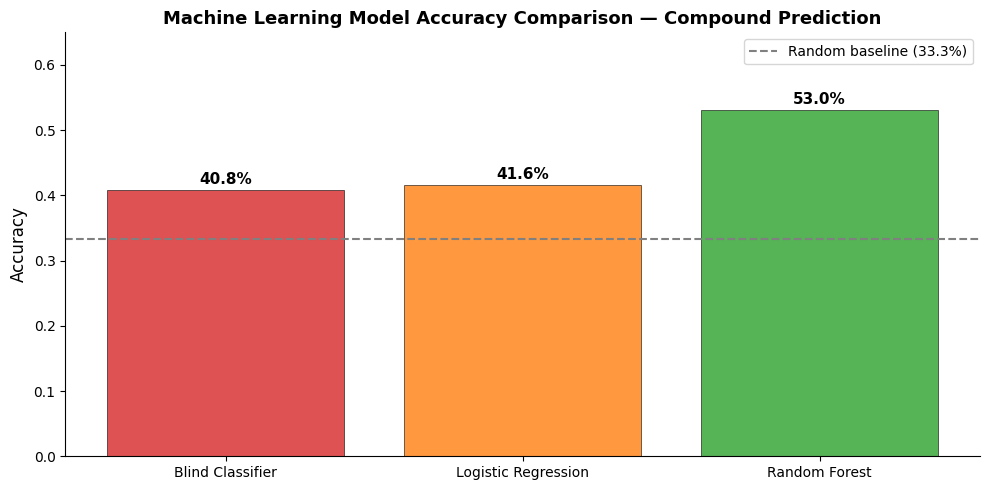

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))

summary_current = summary_df.iloc[-1] # Get the latest model summary
models = ['Blind Classifier', 'Logistic Regression', 'Random Forest']
accuracies = [0.4084, 0.4160, 0.5305]
colours = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']

bars = ax.bar(models, accuracies, color=colours, alpha=0.8, edgecolor='black', linewidth=0.5)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{acc:.1%}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Add random baseline line
ax.axhline(y=0.333, color='grey', linestyle='--', linewidth=1.5, label='Random baseline (33.3%)')

ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Machine Learning Model Accuracy Comparison — Compound Prediction', fontsize=13, fontweight='bold')
ax.set_ylim(0, 0.65)
ax.legend()
ax.yaxis.grid(False)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(figures_dir / 'model_comparison.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

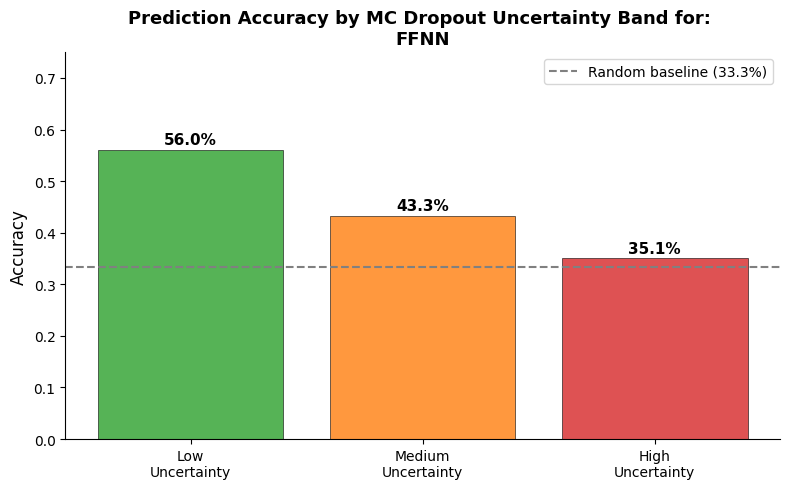

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))

bands = ['Low\nUncertainty', 'Medium\nUncertainty', 'High\nUncertainty']
accuracy = [summary_current['uq_low_acc'], summary_current['uq_med_acc'], summary_current['uq_high_acc']]

colours = ['#2ca02c', '#ff7f0e', '#d62728']

bars = ax.bar(bands, accuracy, color=colours, alpha=0.8, edgecolor='black', linewidth=0.5)

for bar, acc in zip(bars, accuracy):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{acc:.1%}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.axhline(y=0.333, color='grey', linestyle='--', linewidth=1.5, label='Random baseline (33.3%)')
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Prediction Accuracy by MC Dropout Uncertainty Band for: \n'
             'FFNN', fontsize=13, fontweight='bold')
ax.set_ylim(0, 0.75)
ax.legend()
ax.yaxis.grid(False)
ax.xaxis.grid(False)

plt.tight_layout()
plt.savefig(figures_dir / 'uq_accuracy.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

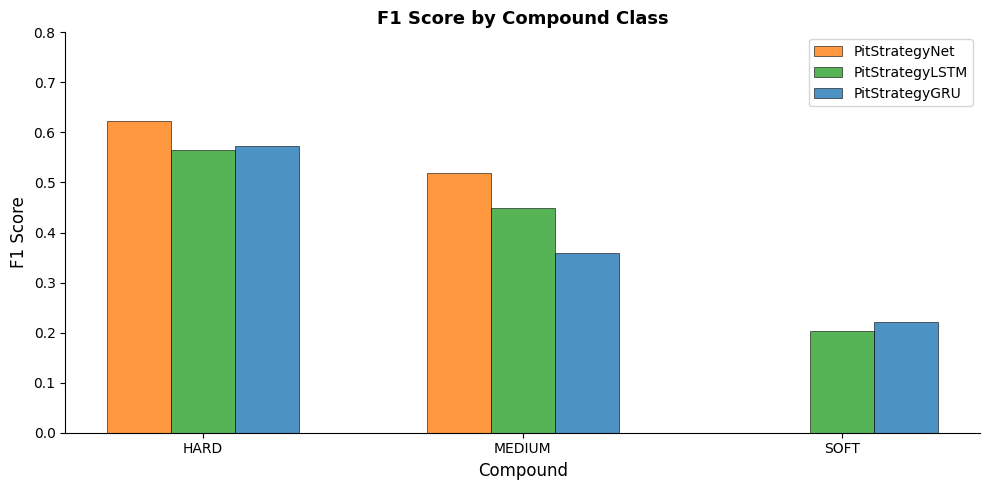

In [31]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(3)
width = 0.2
classes = ['HARD', 'MEDIUM', 'SOFT']
current_net = summary_df.iloc[4]
best_LSTM = summary_df.iloc[11]
best_GRU = summary_df.iloc[17]
models_f1 = {
    current_net['architecture']: [current_net['hard_f1'], current_net['medium_f1'], current_net['soft_f1']],
    best_LSTM['architecture']: [best_LSTM['hard_f1'], best_LSTM['medium_f1'], best_LSTM['soft_f1']],
    best_GRU['architecture']: [best_GRU['hard_f1'], best_GRU['medium_f1'], best_GRU['soft_f1']],
}

colours = ['#ff7f0e', '#2ca02c', '#1f77b4']

for i, (model, f1s) in enumerate(models_f1.items()):
    bars = ax.bar(x + i*width, f1s, width, label=model,
                  color=colours[i], alpha=0.8, edgecolor='black', linewidth=0.5)

ax.set_xlabel('Compound', fontsize=12)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('F1 Score by Compound Class', fontsize=13, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(classes)
ax.legend()
ax.yaxis.grid(False)
ax.xaxis.grid(False)
ax.set_ylim(0, 0.8)

plt.tight_layout()
plt.savefig(figures_dir / 'f1_by_class.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

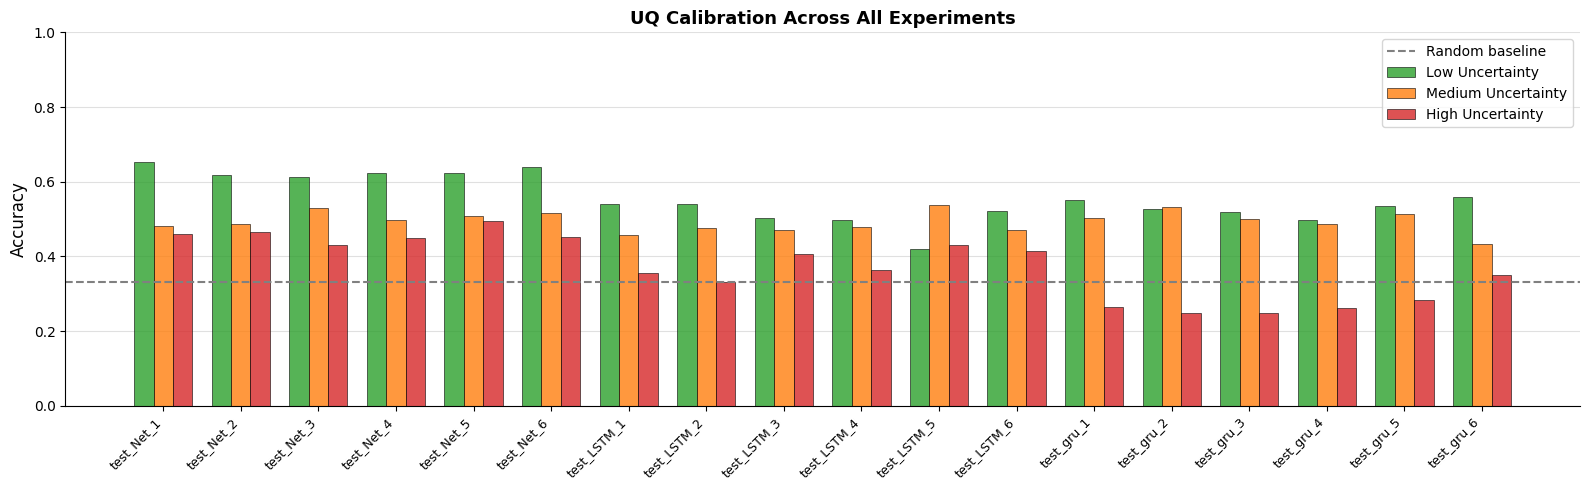

In [24]:
fig, ax = plt.subplots(figsize=(16, 5), facecolor='white')
ax.set_facecolor('white')

exp_names = [e['experiment'] for e in experiments if 'uq_low_acc' in e and 'uq_med_acc' in e and 'uq_high_acc' in e]
low_accs = [e['uq_low_acc']  for e in experiments if 'uq_low_acc' in e and 'uq_med_acc' in e and 'uq_high_acc' in e]
med_accs = [e['uq_med_acc']  for e in experiments if 'uq_low_acc' in e and 'uq_med_acc' in e and 'uq_high_acc' in e]
high_accs = [e['uq_high_acc'] for e in experiments if 'uq_low_acc' in e and 'uq_med_acc' in e and 'uq_high_acc' in e]

x = np.arange(len(exp_names))
width = 0.25  # narrower to fit three bars

ax.bar(x - width, low_accs, width, label='Low Uncertainty', color='#2ca02c', alpha=0.8, edgecolor='black', linewidth=0.5)
ax.bar(x, med_accs, width, label='Medium Uncertainty', color='#ff7f0e', alpha=0.8, edgecolor='black', linewidth=0.5)
ax.bar(x + width, high_accs, width, label='High Uncertainty', color='#d62728', alpha=0.8, edgecolor='black', linewidth=0.5)

ax.axhline(y=0.333, color='grey', linestyle='--', linewidth=1.5, label='Random baseline')
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('UQ Calibration Across All Experiments', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(exp_names, rotation=45, ha='right', fontsize=9)
ax.legend()
ax.yaxis.grid(True, color='#e0e0e0', linewidth=0.8)
ax.xaxis.grid(False)
ax.set_axisbelow(True)
ax.set_ylim(0, 1.0)

plt.tight_layout()
plt.savefig(figures_dir / 'uq_across_experiments.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

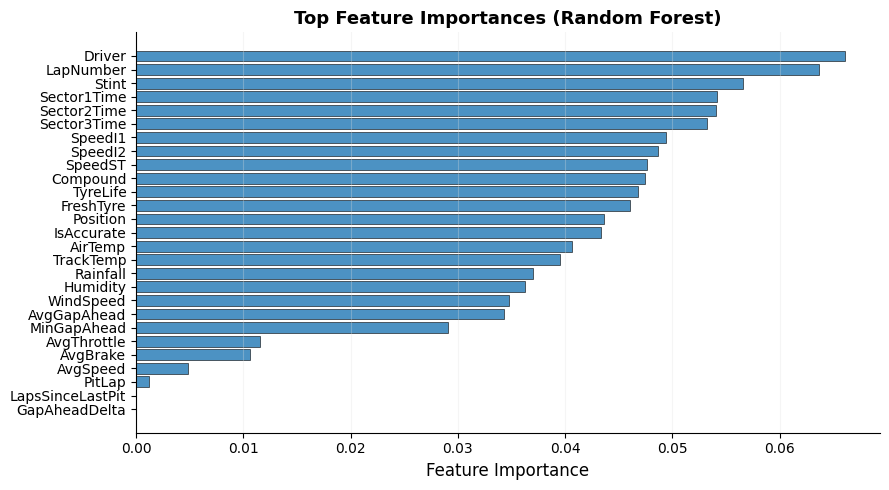

In [25]:
fig, ax = plt.subplots(figsize=(9, 5))

features = list(baseline['feature_importance'].keys())
values = list(sorted(baseline['feature_importance'].values(), reverse=True))

bars = ax.barh(features[::-1], values[::-1], color='#1f77b4', alpha=0.8,
               edgecolor='black', linewidth=0.5)

ax.set_xlabel('Feature Importance', fontsize=12)
ax.set_title('Top Feature Importances (Random Forest)', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

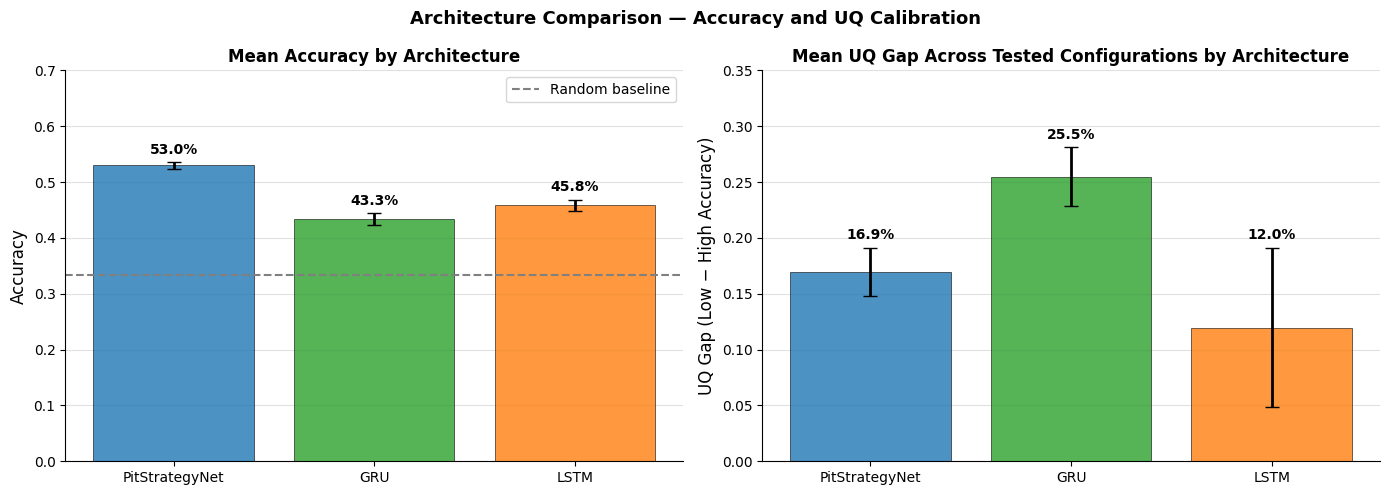

In [29]:
# Architecture comparison with error bars
architectures = {
    'PitStrategyNet': [e for e in experiments if e['architecture'] == 'PitStrategyNet'],
    'GRU': [e for e in experiments if e['architecture'] == 'PitStrategyGRU'],
    'LSTM': [e for e in experiments if e['architecture'] == 'PitStrategyLSTM'],
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='white')

arch_names = list(architectures.keys())
colours    = ['#1f77b4', '#2ca02c', '#ff7f0e']

# Accuracy with error bars
accs  = [[e['accuracy'] for e in runs] for runs in architectures.values()]
means = [np.mean(a) for a in accs]
stds  = [np.std(a)  for a in accs]

bars = axes[0].bar(arch_names, means, color=colours, alpha=0.8,
                   edgecolor='black', linewidth=0.5)
axes[0].errorbar(arch_names, means, yerr=stds, fmt='none',
                 color='black', capsize=5, linewidth=2)
axes[0].axhline(y=0.333, color='grey', linestyle='--', linewidth=1.5, label='Random baseline')
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Mean Accuracy by Architecture', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, 0.7)
axes[0].yaxis.grid(True, color='#e0e0e0', linewidth=0.8)
axes[0].set_axisbelow(True)
axes[0].legend()

for bar, mean, std in zip(bars, means, stds):
    axes[0].text(bar.get_x() + bar.get_width()/2, mean + std + 0.01,
                f'{mean:.1%}', ha='center', va='bottom', fontweight='bold', fontsize=10)

# UQ gap with error bars
uq_gaps  = [[e['uq_low_acc'] - e['uq_high_acc'] for e in runs]
             for runs in architectures.values()]
gap_means = [np.mean(g) for g in uq_gaps]
gap_stds  = [np.std(g)  for g in uq_gaps]

bars2 = axes[1].bar(arch_names, gap_means, color=colours, alpha=0.8,
                    edgecolor='black', linewidth=0.5)
axes[1].errorbar(arch_names, gap_means, yerr=gap_stds, fmt='none',
                 color='black', capsize=5, linewidth=2)
axes[1].set_ylabel('UQ Gap (Low − High Accuracy)', fontsize=12)
axes[1].set_title('Mean UQ Gap Across Tested Configurations by Architecture', fontsize=12, fontweight='bold')
axes[1].set_ylim(0, 0.35)
axes[1].yaxis.grid(True, color='#e0e0e0', linewidth=0.8)
axes[1].set_axisbelow(True)

for bar, mean, std in zip(bars2, gap_means, gap_stds):
    axes[1].text(bar.get_x() + bar.get_width()/2, mean + std + 0.005,
                f'{mean:.1%}', ha='center', va='bottom', fontweight='bold', fontsize=10)

axes[0].set_facecolor('white')
axes[1].set_facecolor('white')

plt.suptitle('Architecture Comparison — Accuracy and UQ Calibration',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(figures_dir / 'architecture_comparison.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()